In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Set styling for plots
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD THE DATASET
# ==========================================

df = pd.read_excel("flood dataset.xlsx", sheet_name="Sheet5")
print("### Dataset Loaded Successfully ###")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- First 5 Rows ---")
print(df.head(), "\n")

# ==========================================
# 3. DATA VISUALIZATION & ANALYSIS (EDA)
# ==========================================
print("### Step 3: Performing Exploratory Data Analysis (EDA) ###")

# A. Descriptive Statistics
print("\n--- Descriptive Statistics ---")
print(df.describe())

# Setup the visualization canvas
plt.figure(figsize=(16, 12))

# 1. Univariate Analysis: Distribution of the Target variable (flood)
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='flood', palette='Set2')
plt.title('Univariate Analysis: Distribution of Floods (0 = No, 1 = Yes)')
plt.xlabel('Flood Occurred')
plt.ylabel('Count')

# 2. Multivariate Analysis: Distribution Plot of Annual Rainfall by Flood status
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='ANNUAL', hue='flood', kde=True, multiple='stack', palette='Blues_r')
plt.title('Multivariate Analysis: Annual Rainfall Distribution vs Flood')
plt.xlabel('Annual Rainfall (mm)')

# 3. Box Plot: Checking Outliers in Meteorological parameters (Humidity vs Flood)
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='flood', y='Humidity', palette='Pastel1')
plt.title('Box Plot: Humidity Distribution vs Flood Status')
plt.xlabel('Flood Occurred')
plt.ylabel('Humidity (%)')

# 4. Correlation Heat Map Matrix
plt.subplot(2, 2, 4)
# drop non-numeric columns if any exist before calculating correlation
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heat Map of Weather & Rainfall Features')

plt.tight_layout()
plt.savefig('flood_analysis_plots.png')
print("\n[Visualizations Saved]: 'flood_analysis_plots.png' has been created in your directory.")
plt.close()

# ==========================================
# 4. DATA PRE-PROCESSING
# ==========================================
print("\n### Step 4: Executing Data Pre-processing ###")

# A. Handling Missing Values
missing_vals = df.isnull().sum()
print("\nMissing values per column before treatment:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found.")

# If any missing values exist, we fill them with the column median
df = df.fillna(df.median(numeric_only=True))

# B. Detecting and Treating Outliers using the Interquartile Range (IQR) Method
Q1 = df['ANNUAL'].quantile(0.25)
Q3 = df['ANNUAL'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers to upper and lower bounds to maintain data stability
df['ANNUAL'] = np.where(df['ANNUAL'] > upper_bound, upper_bound, df['ANNUAL'])
df['ANNUAL'] = np.where(df['ANNUAL'] < lower_bound, lower_bound, df['ANNUAL'])
print("-> Outliers processed and capped using IQR boundaries.")

# C. Splitting Dependent (y) and Independent (X) Variables
X = df.drop(columns=['flood']) # Independent features (Weather parameters/Rainfall)
y = df['flood']               # Dependent variable (Target class)

# D. Creating Training and Testing Datasets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"-> Train-Test Split complete.")
print(f"   Training Set Shape: {X_train.shape}")
print(f"   Testing Set Shape: {X_test.shape}")

# E. Applying Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("-> Feature scaling (StandardScaler) applied successfully to numerical inputs.")

print("\n### Pre-processing complete! Ready for Model Building. ###")

### Dataset Loaded Successfully ###
Dataset Shape: 115 rows, 11 columns

--- First 5 Rows ---
   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  flood  
0  274.866667  649.9      0  
1  130.300000  256.4      1  
2  186.200000  308.9      0  
3  366.066667  862.5      0  
4  283.400000  586.9      0   

### Step 3: Performing Exploratory Data Analysis (EDA) ###

--- Descriptive Statistics ---
             Temp    Humidity  Cloud Cover       ANNUAL     Jan-Feb  \
count  115.000000  115.000000   115.000000   115.000000  115.000000   
mean    29.600000   73

C:\Users\thadi\AppData\Local\Temp\ipykernel_15464\4041197138.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='flood', palette='Set2')
C:\Users\thadi\AppData\Local\Temp\ipykernel_15464\4041197138.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='flood', y='Humidity', palette='Pastel1')



[Visualizations Saved]: 'flood_analysis_plots.png' has been created in your directory.

### Step 4: Executing Data Pre-processing ###

Missing values per column before treatment:
No missing values found.
-> Outliers processed and capped using IQR boundaries.
-> Train-Test Split complete.
   Training Set Shape: (92, 10)
   Testing Set Shape: (23, 10)
-> Feature scaling (StandardScaler) applied successfully to numerical inputs.

### Pre-processing complete! Ready for Model Building. ###


In [38]:
print("="*60)
print("DATASET INFORMATION")

print("="*60)

print(df.info())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB
None


In [39]:
print("="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

MISSING VALUES
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64


In [40]:
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

print(df.describe())

DESCRIPTIVE STATISTICS
             Temp    Humidity  Cloud Cover      ANNUAL     Jan-Feb  \
count  115.000000  115.000000   115.000000   115.00000  115.000000   
mean    29.600000   73.852174    36.286957  2919.81913   27.739130   
std      1.122341    2.947623     4.330158   405.96097   22.361032   
min     28.000000   70.000000    30.000000  2068.80000    0.300000   
25%     29.000000   71.000000    32.500000  2627.90000   10.250000   
50%     30.000000   74.000000    36.000000  2937.50000   20.500000   
75%     31.000000   76.000000    40.000000  3164.10000   41.600000   
max     31.000000   79.000000    44.000000  3968.40000   98.100000   

          Mar-May      Jun-Sep     Oct-Dec     avgjune         sub       flood  
count  115.000000   115.000000  115.000000  115.000000  115.000000  115.000000  
mean   377.253913  2022.840870  497.636522  218.100870  439.801739    0.139130  
std    151.091850   386.254397  129.860643   62.547597  210.438813    0.347597  
min     89.900000  110

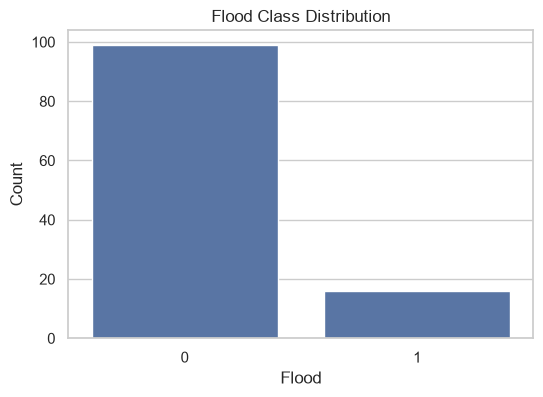

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='flood', data=df)

plt.title("Flood Class Distribution")
plt.xlabel("Flood")
plt.ylabel("Count")

plt.show()

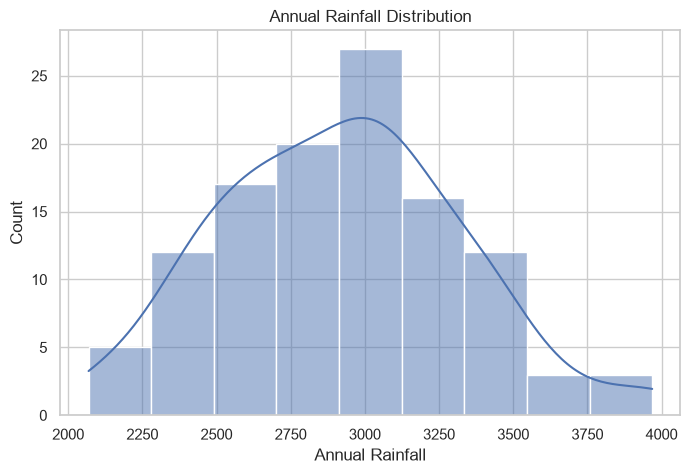

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(df['ANNUAL'], kde=True)

plt.title("Annual Rainfall Distribution")
plt.xlabel("Annual Rainfall")
plt.show()

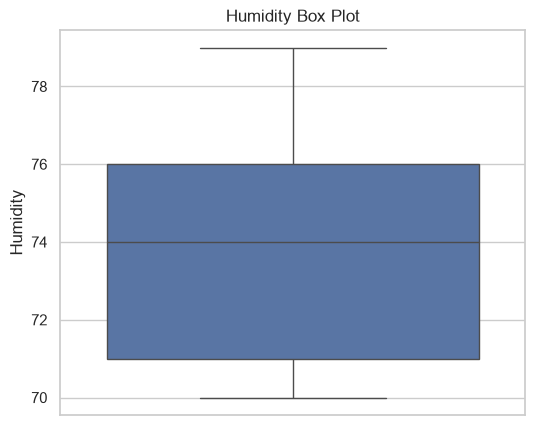

In [43]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df['Humidity'])

plt.title("Humidity Box Plot")

plt.show()

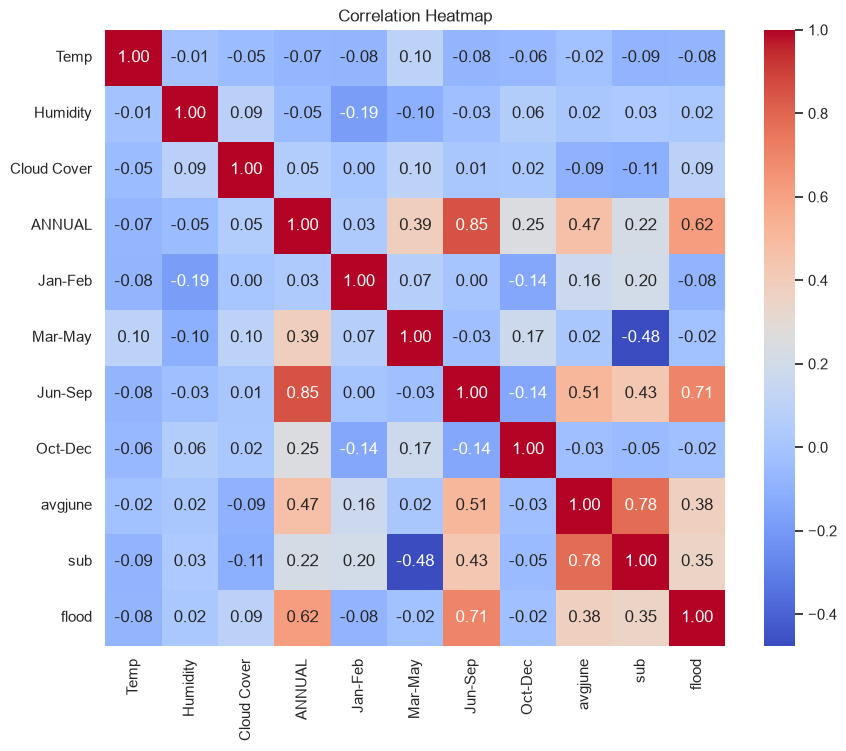

In [44]:
plt.figure(figsize=(10,8))

corr=df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [45]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0
...,...,...,...,...,...,...,...,...,...,...,...
110,28,71,30,3035.1,66.2,313.5,2209.1,446.3,262.833333,664.3,0
111,29,71,37,2151.1,18.3,287.4,1535.6,309.8,143.433333,335.0,0
112,30,74,42,3255.4,43.9,218.5,2561.2,431.8,347.566667,923.4,1
113,31,71,31,3046.4,14.9,364.5,2164.8,502.1,151.466667,203.4,0


In [46]:
import numpy as np

numeric_columns=df.select_dtypes(include=np.number).columns

numeric_columns=numeric_columns.drop("flood")

for col in numeric_columns:

    Q1=df[col].quantile(0.25)

    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    df[col]=np.clip(df[col],lower,upper)

print("Outliers Treated Successfully")

Outliers Treated Successfully


In [47]:
X=df.drop("flood",axis=1)

y=df["flood"]

In [48]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.20,

random_state=42,

stratify=y
)

print(X_train.shape)

print(X_test.shape)

(92, 10)
(23, 10)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred=dt.predict(X_test)

dt_acc=accuracy_score(y_test,dt_pred)

print("Decision Tree Accuracy:",dt_acc)

Decision Tree Accuracy: 0.9565217391304348


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

rf_acc=accuracy_score(y_test,rf_pred)

print("Random Forest Accuracy:",rf_acc)

Random Forest Accuracy: 0.9565217391304348


In [52]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred=knn.predict(X_test)

knn_acc=accuracy_score(y_test,knn_pred)

print("KNN Accuracy:",knn_acc)

KNN Accuracy: 0.8695652173913043


In [53]:
from xgboost import XGBClassifier

xgb=XGBClassifier(

random_state=42,

eval_metric='logloss'

)

xgb.fit(X_train,y_train)

xgb_pred=xgb.predict(X_test)

xgb_acc=accuracy_score(y_test,xgb_pred)

print("XGBoost Accuracy:",xgb_acc)

XGBoost Accuracy: 0.8695652173913043


In [59]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

models={

"Decision Tree":dt_pred,

"Random Forest":rf_pred,

"KNN":knn_pred,

"XGBoost":xgb_pred

}

for name,pred in models.items():

    print("="*60)

    print(name)

    print("Accuracy:",accuracy_score(y_test,pred))

    print()

    print(confusion_matrix(y_test,pred))

    print()

    print(classification_report(y_test,pred))

Decision Tree
Accuracy: 0.9565217391304348

[[20  0]
 [ 1  2]]

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23

Random Forest
Accuracy: 0.9565217391304348

[[20  0]
 [ 1  2]]

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23

KNN
Accuracy: 0.8695652173913043

[[19  1]
 [ 2  1]]

              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.50      0.33      0.40         3



C:\Users\thadi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thadi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thadi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [55]:
dt.fit(X_train,y_train)
rf.fit(X_train,y_train)
knn.fit(X_train,y_train)
xgb.fit(X_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
import pandas as pd

results=pd.DataFrame({

'Model':['Decision Tree',

'Random Forest',

'KNN',

'XGBoost'],

'Accuracy':[

dt_acc,

rf_acc,

knn_acc,

xgb_acc

]

})

print(results)

results.sort_values(by='Accuracy',ascending=False,inplace=True)

print()

print(results)

           Model  Accuracy
0  Decision Tree  0.956522
1  Random Forest  0.956522
2            KNN  0.869565
3        XGBoost  0.869565

           Model  Accuracy
0  Decision Tree  0.956522
1  Random Forest  0.956522
2            KNN  0.869565
3        XGBoost  0.869565


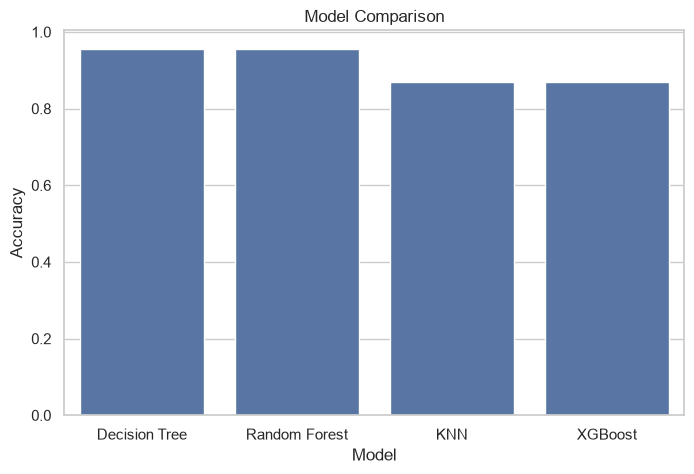

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(

x='Model',

y='Accuracy',

data=results

)

plt.title("Model Comparison")

plt.show()

In [32]:
import joblib

joblib.dump(xgb,"floods.save")

joblib.dump(scaler,"scaler.save")

print("Model Saved Successfully")

Model Saved Successfully


In [60]:
dt_acc
rf_acc
knn_acc
xgb_acc


0.8695652173913043

In [61]:
from sklearn.metrics import accuracy_score

dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
knn_acc = accuracy_score(y_test, knn_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

In [62]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],
    "Accuracy": [
        dt_acc,
        rf_acc,
        knn_acc,
        xgb_acc
    ]
})

print(results)

           Model  Accuracy
0  Decision Tree  0.956522
1  Random Forest  0.956522
2            KNN  0.869565
3        XGBoost  0.869565


In [63]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

           Model  Accuracy
0  Decision Tree  0.956522
1  Random Forest  0.956522
2            KNN  0.869565
3        XGBoost  0.869565


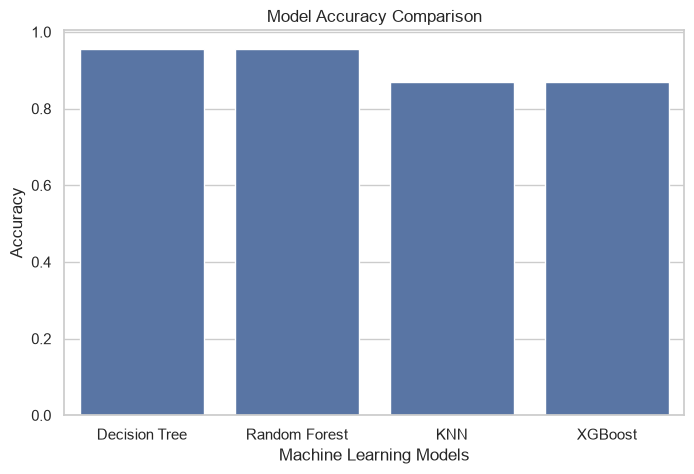

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy")

plt.show()

In [65]:
best_model = results.iloc[0]

print("="*50)

print("BEST MODEL")

print("="*50)

print("Model :", best_model["Model"])

print("Accuracy :", round(best_model["Accuracy"]*100,2),"%")

BEST MODEL
Model : Decision Tree
Accuracy : 95.65 %


In [66]:
print("\nMODEL PERFORMANCE SUMMARY")

print(results.to_string(index=False))


MODEL PERFORMANCE SUMMARY
        Model  Accuracy
Decision Tree  0.956522
Random Forest  0.956522
          KNN  0.869565
      XGBoost  0.869565


In [67]:
import joblib

# Dictionary of trained models
model_dict = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "XGBoost": xgb
}

# Get the best model name from the comparison table
best_model_name = results.iloc[0]["Model"]

# Select the best model object
best_model = model_dict[best_model_name]

print("Best Model :", best_model_name)

# Save the best model and scaler
joblib.dump(best_model, "floods.save")
joblib.dump(scaler, "scaler.save")

print("Model saved as floods.save")
print("Scaler saved as scaler.save")

Best Model : Decision Tree
Model saved as floods.save
Scaler saved as scaler.save


In [68]:
import os

print(os.path.exists("floods.save"))
print(os.path.exists("scaler.save"))

True
True
